Data cleaning

In [1]:
# import libraries
import pandas as pd

#import dataset
df = pd.read_csv("cats_dataset.csv")

In [2]:
#preview data
print(df.head())

              Breed  Age (Years)  Weight (kg)          Color  Gender
0      Russian Blue           19            7  Tortoiseshell  Female
1  Norwegian Forest           19            9  Tortoiseshell  Female
2         Chartreux            3            3          Brown  Female
3           Persian           13            6          Sable  Female
4           Ragdoll           10            8          Tabby    Male


In [3]:
# Display data types and non-null counts
# df.info() shows the data types of each column and the number of non-null entries (useful for spotting missing values).
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Breed        1000 non-null   object
 1   Age (Years)  1000 non-null   int64 
 2   Weight (kg)  1000 non-null   int64 
 3   Color        1000 non-null   object
 4   Gender       1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
None


In [4]:
# Get summary statistics for numerical columns
# df.describe() gives you summary statistics for numerical columns (mean, standard deviation, min, max, etc.).
print(df.describe())

       Age (Years)  Weight (kg)
count  1000.000000   1000.00000
mean     10.210000      5.55000
std       5.535751      2.22676
min       1.000000      2.00000
25%       5.000000      4.00000
50%      10.000000      6.00000
75%      15.000000      7.00000
max      19.000000      9.00000


In [5]:
#check missing data
print(df.isnull().sum())


Breed          0
Age (Years)    0
Weight (kg)    0
Color          0
Gender         0
dtype: int64


In [6]:
#check duplicate row
duplicates = df[df.duplicated()]

# Display duplicate rows
print(duplicates)

            Breed  Age (Years)  Weight (kg)    Color  Gender
69         Birman           17            7  Pointed  Female
233       Persian           13            6    Sable  Female
405  Egyptian Mau            2            9     Gray    Male
653        Ocicat           14            8    Cream    Male
834        Bengal           18            5    Brown  Female


In [7]:
# Count total duplicates in the DataFrame
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 5


In [8]:
#delete duplicate
df = df.drop_duplicates()

# Count total duplicates in the DataFrame
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

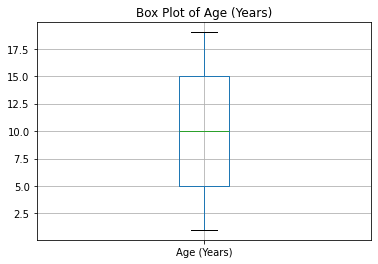

In [10]:
#check outlier using box plot

# Box plot for Age (Years)
df.boxplot(column='Age (Years)')
plt.title('Box Plot of Age (Years)')
plt.show()

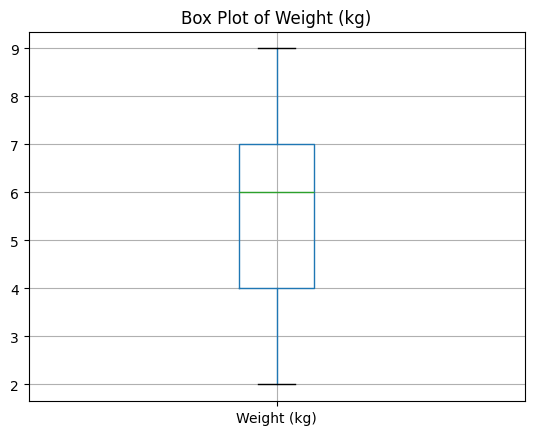

In [11]:
# Box plot for Weight (kg)
df.boxplot(column='Weight (kg)')
plt.title('Box Plot of Weight (kg)')
plt.show()

/tmp/ipykernel_3370/1070303674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Breed", y="Weight (kg)", data=df, palette="Set2")


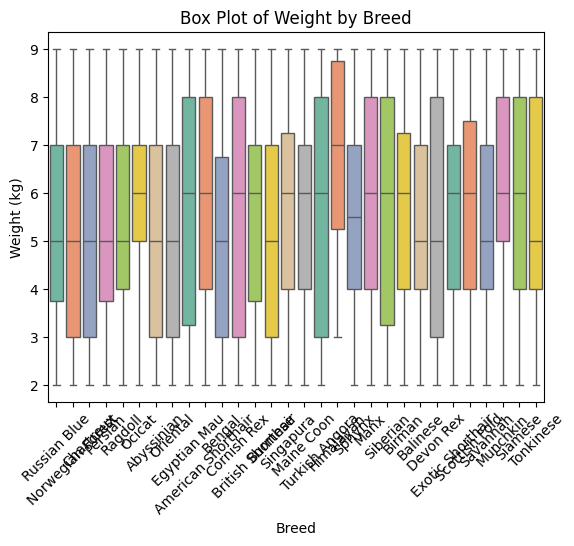

In [12]:
#check outlier using box plot(using seaborn libraries)
# Create a box plot
sns.boxplot(x="Breed", y="Weight (kg)", data=df, palette="Set2")

# Add a title and labels
plt.title("Box Plot of Weight by Breed")
plt.xlabel("Breed")
plt.ylabel("Weight (kg)")

# Rotate x-axis labels for better readability if there are many breeds
plt.xticks(rotation=45)

# Display the plot
plt.show()

/tmp/ipykernel_3370/4033524551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Gender", y="Age (Years)", data=df, palette="Set3")


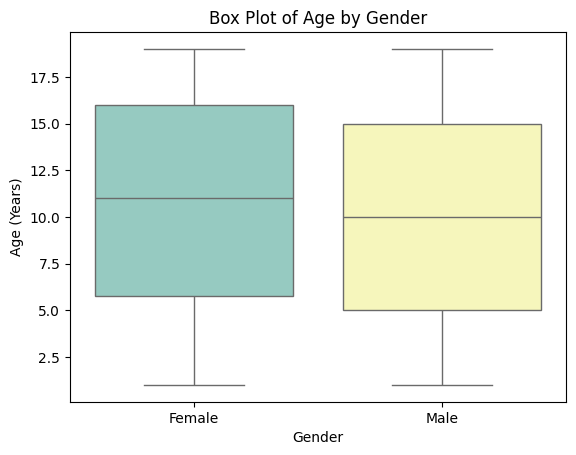

In [13]:
# Create a box plot
sns.boxplot(x="Gender", y="Age (Years)", data=df, palette="Set3")

# Add a title and labels
plt.title("Box Plot of Age by Gender")
plt.xlabel("Gender")
plt.ylabel("Age (Years)")

# Display the plot
plt.show()


In [14]:
#remove outliers

Q1 = df['Age (Years)'].quantile(0.25)
Q3 = df['Age (Years)'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['Age (Years)'] < (Q1 - 1.5 * IQR)) | (df['Age (Years)'] > (Q3 + 1.5 * IQR)))]

Q1 = df['Weight (kg)'].quantile(0.25)
Q3 = df['Weight (kg)'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['Weight (kg)'] < (Q1 - 1.5 * IQR)) | (df['Weight (kg)'] > (Q3 + 1.5 * IQR)))]



In [15]:
#convert data type(make sure column has correct data type)

df['Age (Years)'] = pd.to_numeric(df['Age (Years)'], errors='coerce')

df['Weight (kg)'] = pd.to_numeric(df['Weight (kg)'], errors='coerce')


In [16]:
#save the clean data

df.to_csv('cleaned_cats_dataset.csv', index=False)
